# 🍜 Task 3: Cuisine Classification
**Cognifyz Technologies — Machine Learning Internship**

---
**Objective:** Develop a machine learning model to classify restaurants based on their cuisines.

**Steps:**
1. Preprocess the dataset by handling missing values and encoding categorical variables.
2. Split the data into training and testing sets.
3. Select a classification algorithm (e.g., logistic regression, random forest) and train it on the training data.
4. Evaluate the model's performance using appropriate classification metrics (e.g., accuracy, precision, recall).
5. Analyze the model's performance across different cuisines and identify any challenges or biases.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

os.makedirs('plots', exist_ok=True)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('Dataset .csv')
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset Shape: 9,551 rows × 21 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


## 3. Step 1 — Preprocess: Handle Missing Values & Encode Categoricals

In [3]:
# Handle missing values
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df['Cuisines'] = df['Cuisines'].fillna('Unknown')
print(f'\nAfter filling: {df.isnull().sum().sum()} missing values')
print('✅ Missing values handled.')

Missing values:
Cuisines    9
dtype: int64

After filling: 0 missing values
✅ Missing values handled.


In [4]:
# Extract primary cuisine (first listed cuisine)
df['Primary_Cuisine'] = df['Cuisines'].str.split(', ').str[0]

print(f'Total unique primary cuisines: {df["Primary_Cuisine"].nunique()}')
print('\nTop 15 Primary Cuisines:')
print(df['Primary_Cuisine'].value_counts().head(15).to_string())

Total unique primary cuisines: 120

Top 15 Primary Cuisines:
Primary_Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150


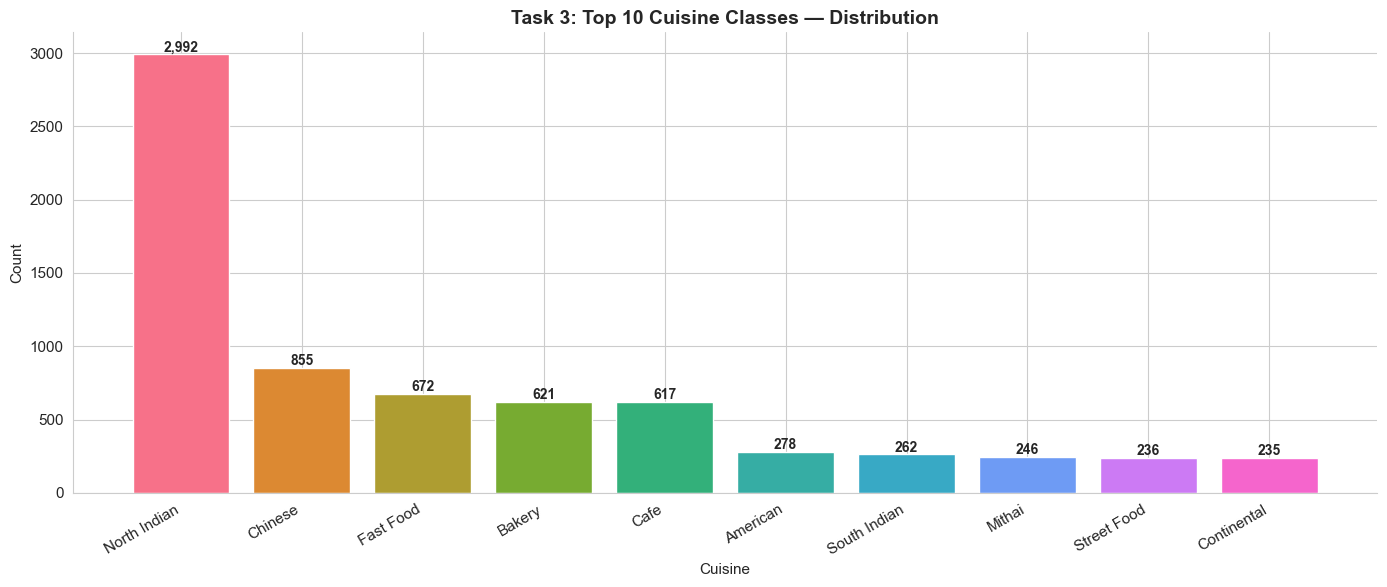


Filtered dataset: 7,014 restaurants across 10 cuisines


In [5]:
# Keep top 10 cuisines for balanced classification
TOP_N = 10
top_cuisines = df['Primary_Cuisine'].value_counts().head(TOP_N).index.tolist()
df_model = df[df['Primary_Cuisine'].isin(top_cuisines)].copy()

# Visualize class distribution
counts = df_model['Primary_Cuisine'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('husl', TOP_N)
bars = ax.bar(counts.index, counts.values, color=palette, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title(f'Task 3: Top {TOP_N} Cuisine Classes — Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Cuisine')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/task3_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFiltered dataset: {len(df_model):,} restaurants across {TOP_N} cuisines')

In [6]:
# Encode categorical features
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0}).fillna(0)

# City encoding
top_cities = df_model['City'].value_counts().head(20).index
df_model['City_enc'] = df_model['City'].apply(lambda x: x if x in top_cities else 'Other')
le_city = LabelEncoder()
df_model['City_enc'] = le_city.fit_transform(df_model['City_enc'])

# Country encoding
le_country = LabelEncoder()
df_model['Country_enc'] = le_country.fit_transform(df_model['Country Code'].astype(str))

# Target encoding
le_cuisine = LabelEncoder()
y = le_cuisine.fit_transform(df_model['Primary_Cuisine'])
cuisine_classes = le_cuisine.classes_

print('✅ Categorical variables encoded.')
print(f'   Target classes: {list(cuisine_classes)}')

✅ Categorical variables encoded.
   Target classes: ['American', 'Bakery', 'Cafe', 'Chinese', 'Continental', 'Fast Food', 'Mithai', 'North Indian', 'South Indian', 'Street Food']


## 4. Step 2 — Split into Training and Testing Sets

In [7]:
features = [
    'Average Cost for two',
    'Price range',
    'Aggregate rating',
    'Votes',
    'Has Table booking',
    'Has Online delivery',
    'City_enc',
    'Country_enc'
]

X = df_model[features]

# Stratified 80/20 split (preserves class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train set : {len(X_train):,} samples')
print(f'Test set  : {len(X_test):,} samples')
print(f'Features  : {features}')
print('✅ Data split complete (Stratified 80/20).')

Train set : 5,611 samples
Test set  : 1,403 samples
Features  : ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Has Table booking', 'Has Online delivery', 'City_enc', 'Country_enc']
✅ Data split complete (Stratified 80/20).


## 5. Step 3 — Select & Train Classification Algorithms

In [8]:
classifiers = {
    'Logistic Regression' : (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree'       : (DecisionTreeClassifier(max_depth=10, random_state=42), False),
    'Random Forest'       : (RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1), False),
    'Gradient Boosting'   : (GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42), False)
}

clf_results = {}
print('Training classifiers...')
print('-' * 75)

for name, (clf, use_scaled) in classifiers.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    clf_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
                          'clf': clf, 'y_pred': y_pred, 'scaled': use_scaled}
    print(f'{name:22s} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}')

print('-' * 75)
print('✅ All classifiers trained!')

Training classifiers...
---------------------------------------------------------------------------
Logistic Regression    | Acc=0.4519 | Prec=0.3012 | Rec=0.4519 | F1=0.2962
Decision Tree          | Acc=0.4326 | Prec=0.3794 | Rec=0.4326 | F1=0.3850
Random Forest          | Acc=0.4626 | Prec=0.3963 | Rec=0.4626 | F1=0.3834
Gradient Boosting      | Acc=0.4654 | Prec=0.4016 | Rec=0.4654 | F1=0.3999
---------------------------------------------------------------------------
✅ All classifiers trained!


## 6. Step 4 — Evaluate Classification Metrics

In [9]:
# Results table
results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['clf', 'y_pred', 'scaled']}
    for name, vals in clf_results.items()
}).T.round(4)

print('=== CLASSIFICATION METRICS COMPARISON ===')
display(results_df.sort_values('Accuracy', ascending=False).style.background_gradient(cmap='Greens'))

=== CLASSIFICATION METRICS COMPARISON ===


,Accuracy,Precision,Recall,F1
Gradient Boosting,0.465400,0.401600,0.465400,0.399900
Random Forest,0.462600,0.396300,0.462600,0.383400
Logistic Regression,0.451900,0.301200,0.451900,0.296200
Decision Tree,0.432600,0.379400,0.432600,0.385000


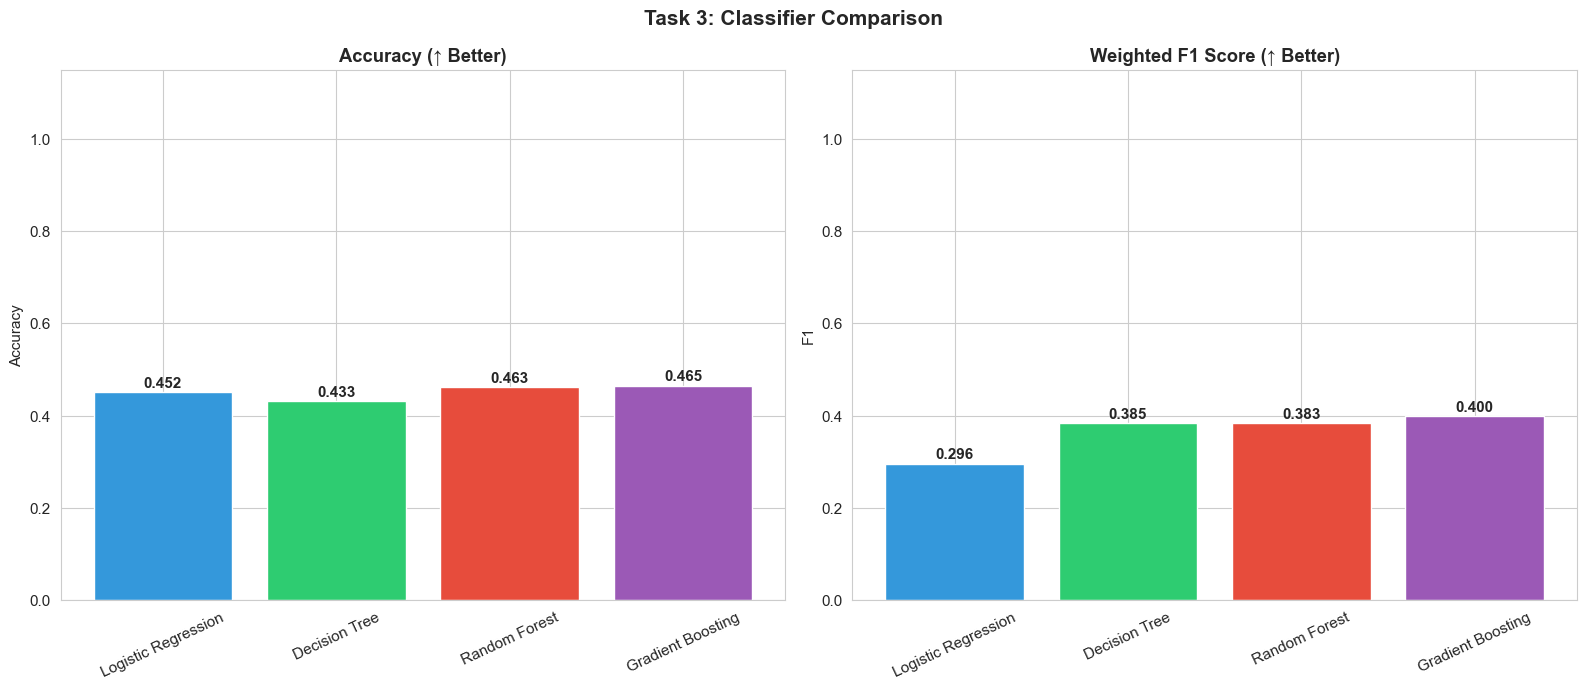

In [10]:
# Metric bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
model_names = list(clf_results.keys())
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, metric, title in zip(axes, ['Accuracy', 'F1'], ['Accuracy', 'Weighted F1 Score']):
    vals = [clf_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=palette, edgecolor='white')
    ax.set_title(f'{title} (↑ Better)', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Task 3: Classifier Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/task3_classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 Best Model: Gradient Boosting
   Accuracy  : 0.4654 (46.5%)
   Precision : 0.4016
   Recall    : 0.4654
   F1 Score  : 0.3999


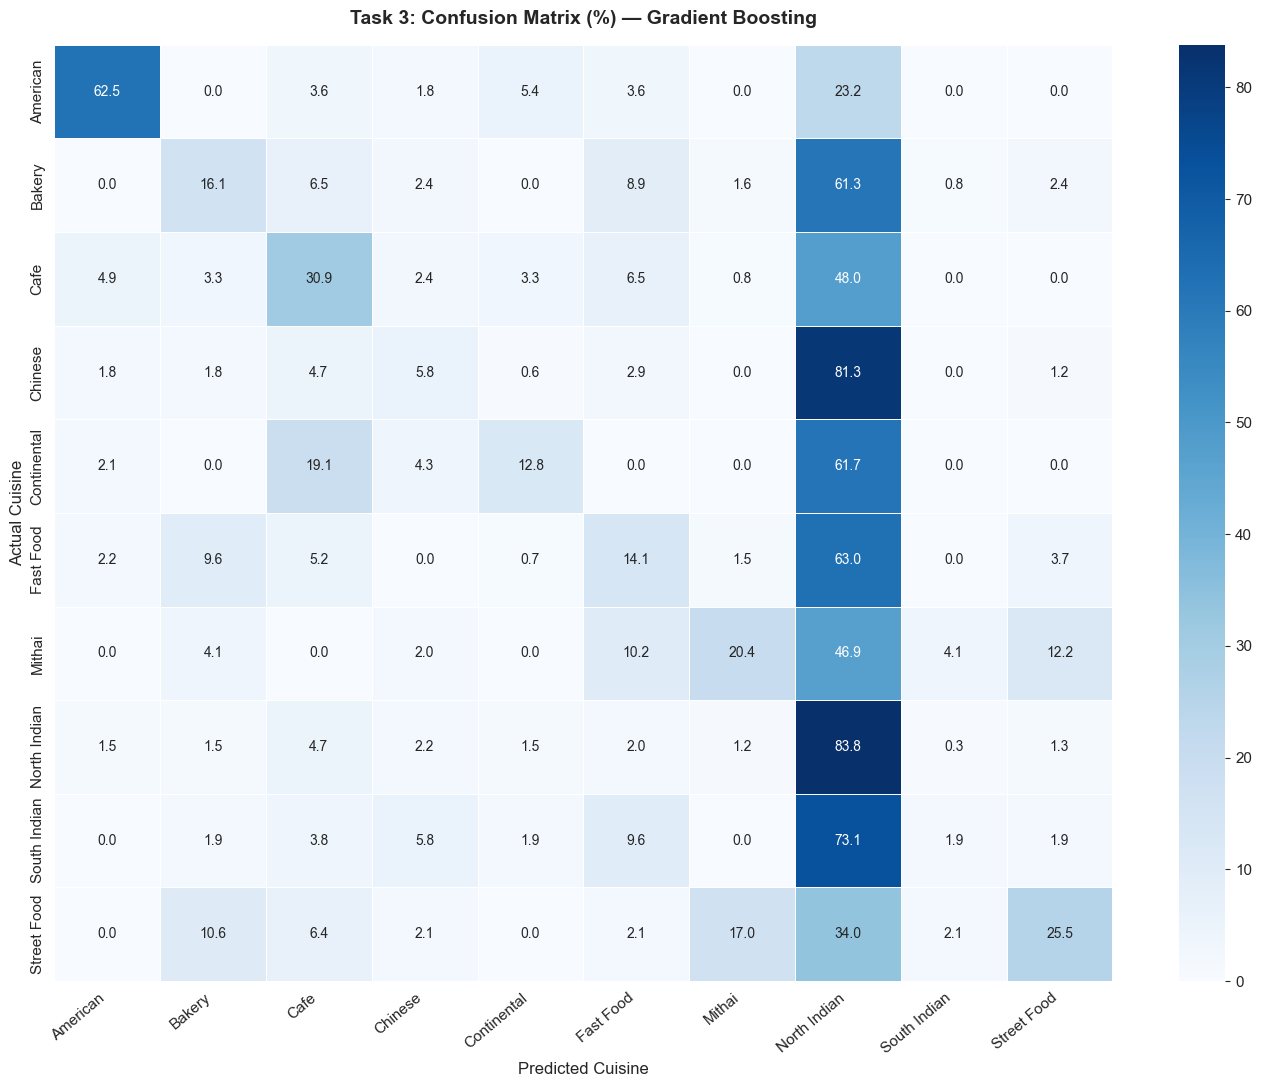

In [11]:
# Best model — Confusion Matrix
best_name = max(clf_results, key=lambda k: clf_results[k]['Accuracy'])
best = clf_results[best_name]
y_pred_best = best['y_pred']

print(f'🏆 Best Model: {best_name}')
print(f'   Accuracy  : {best["Accuracy"]:.4f} ({best["Accuracy"]*100:.1f}%)')
print(f'   Precision : {best["Precision"]:.4f}')
print(f'   Recall    : {best["Recall"]:.4f}')
print(f'   F1 Score  : {best["F1"]:.4f}')

cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=cuisine_classes, yticklabels=cuisine_classes,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
ax.set_title(f'Task 3: Confusion Matrix (%) — {best_name}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Cuisine', fontsize=12)
ax.set_ylabel('Actual Cuisine', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('plots/task3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Full classification report
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_best, target_names=cuisine_classes, zero_division=0))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    American       0.61      0.62      0.62        56
      Bakery       0.35      0.16      0.22       124
        Cafe       0.36      0.31      0.33       123
     Chinese       0.27      0.06      0.10       171
 Continental       0.24      0.13      0.17        47
   Fast Food       0.28      0.14      0.19       135
      Mithai       0.33      0.20      0.25        49
North Indian       0.51      0.84      0.64       599
South Indian       0.14      0.02      0.03        52
 Street Food       0.32      0.26      0.29        47

    accuracy                           0.47      1403
   macro avg       0.34      0.27      0.28      1403
weighted avg       0.40      0.47      0.40      1403



## 7. Step 5 — Analyze Performance Across Cuisines & Identify Biases

In [13]:
# Per-class metrics
from sklearn.metrics import precision_recall_fscore_support

prec_arr, rec_arr, f1_arr, support_arr = precision_recall_fscore_support(
    y_test, y_pred_best, zero_division=0
)

per_class = pd.DataFrame({
    'Cuisine'   : cuisine_classes,
    'Precision' : prec_arr.round(3),
    'Recall'    : rec_arr.round(3),
    'F1 Score'  : f1_arr.round(3),
    'Support'   : support_arr
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

display(per_class.style.background_gradient(subset=['F1 Score', 'Precision', 'Recall'], cmap='RdYlGn'))

,Cuisine,Precision,Recall,F1 Score,Support
0,North Indian,0.512000,0.838000,0.636000,599
1,American,0.614000,0.625000,0.619000,56
2,Cafe,0.362000,0.309000,0.333000,123
3,Street Food,0.324000,0.255000,0.286000,47
4,Mithai,0.333000,0.204000,0.253000,49
5,Bakery,0.351000,0.161000,0.221000,124
6,Fast Food,0.279000,0.141000,0.187000,135
7,Continental,0.240000,0.128000,0.167000,47
8,Chinese,0.270000,0.058000,0.096000,171
9,South Indian,0.143000,0.019000,0.034000,52


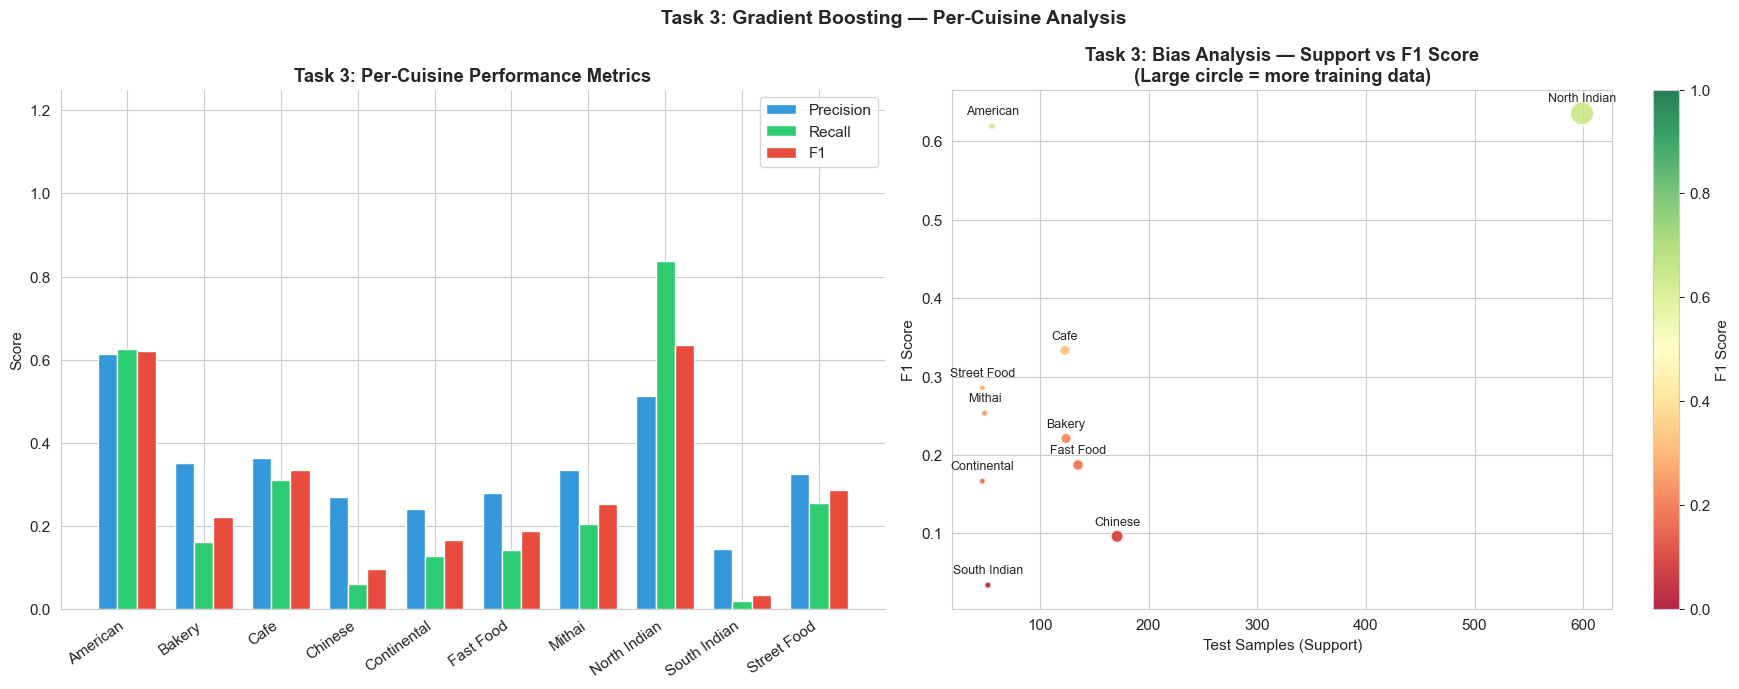

In [14]:
# Bias analysis chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Per-class F1 grouped bar
x = np.arange(len(cuisine_classes))
w = 0.25
axes[0].bar(x - w, prec_arr, w, label='Precision', color='#3498db', edgecolor='white')
axes[0].bar(x,     rec_arr,  w, label='Recall',    color='#2ecc71', edgecolor='white')
axes[0].bar(x + w, f1_arr,   w, label='F1',        color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cuisine_classes, rotation=35, ha='right')
axes[0].set_title('Task 3: Per-Cuisine Performance Metrics', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.25)
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Support vs F1 scatter (bias visualization)
sc = axes[1].scatter(support_arr, f1_arr, s=support_arr * 0.5,
                     c=f1_arr, cmap='RdYlGn', alpha=0.85,
                     vmin=0, vmax=1, edgecolors='white', linewidth=1.5)
for i, cuisine in enumerate(cuisine_classes):
    axes[1].annotate(cuisine, (support_arr[i], f1_arr[i]),
                     fontsize=9, ha='center', va='bottom',
                     xytext=(0, 6), textcoords='offset points')
plt.colorbar(sc, ax=axes[1], label='F1 Score')
axes[1].set_title('Task 3: Bias Analysis — Support vs F1 Score\n(Large circle = more training data)',
                   fontweight='bold')
axes[1].set_xlabel('Test Samples (Support)')
axes[1].set_ylabel('F1 Score')

plt.suptitle(f'Task 3: {best_name} — Per-Cuisine Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/task3_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

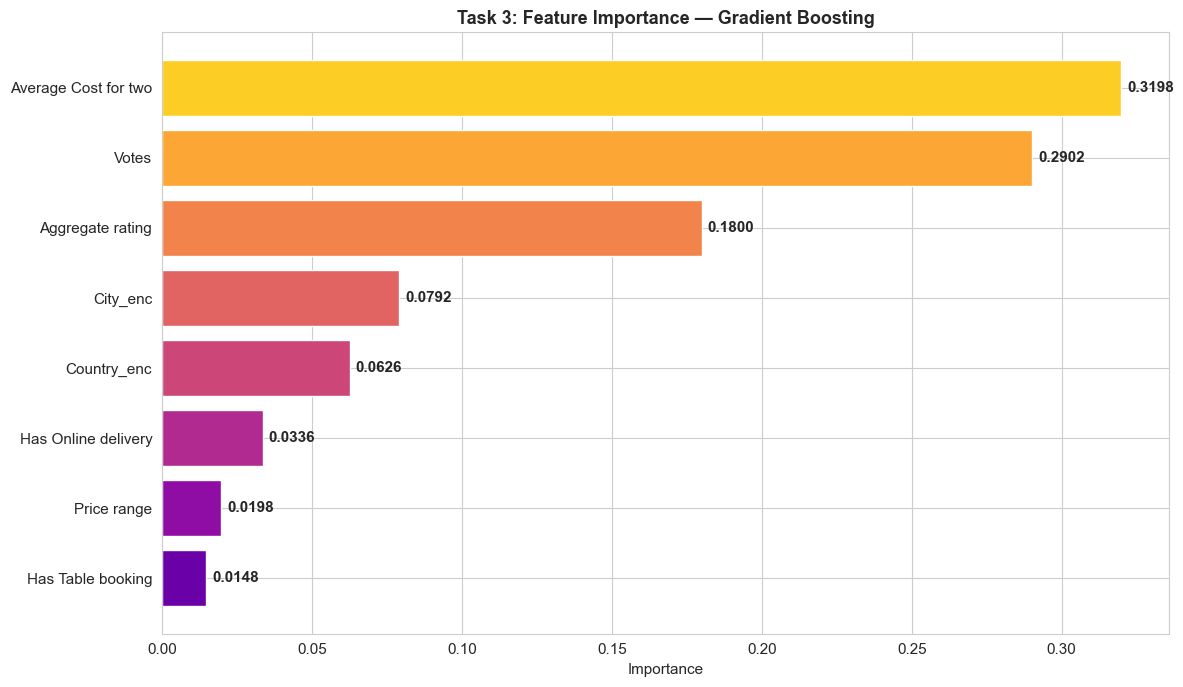

In [15]:
# Feature Importance
best_clf_obj = best['clf']
if hasattr(best_clf_obj, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': best_clf_obj.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(features)))
    bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
    for bar, val in zip(bars, feat_imp['Importance']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Task 3: Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plots/task3_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Summary

In [16]:
print('=' * 65)
print('       TASK 3 SUMMARY — CUISINE CLASSIFICATION')
print('=' * 65)
print(f'📌 Number of Classes    : {TOP_N} (top primary cuisines)')
print(f'📌 Training Samples     : {len(X_train):,}')
print(f'📌 Test Samples         : {len(X_test):,}')
print(f'📌 Features Used        : {len(features)}')
print()
print('📊 Model Results:')
for name, v in sorted(clf_results.items(), key=lambda x: x[1]['Accuracy'], reverse=True):
    marker = '🏆' if name == best_name else '  '
    print(f' {marker} {name:22s}: Acc={v["Accuracy"]:.4f}  F1={v["F1"]:.4f}')
print()
print(f'🏆 Best Model     : {best_name}')
print(f'   Accuracy       : {best["Accuracy"]:.4f} ({best["Accuracy"]*100:.1f}%)')
print(f'   Precision      : {best["Precision"]:.4f}')
print(f'   Recall         : {best["Recall"]:.4f}')
print(f'   F1 Score       : {best["F1"]:.4f}')
print()
print('⚠️ Bias Analysis:')
low_f1 = per_class[per_class['F1 Score'] < 0.5]
if len(low_f1) > 0:
    for _, row in low_f1.iterrows():
        print(f'   Low F1 ({row["F1 Score"]:.3f}) for {row["Cuisine"]} — may be under-represented')
else:
    print('   All cuisines have reasonable F1 scores.')
print()
print('🔑 Key Insight: City location and price range are the most')
print('   important features for predicting cuisine type.')
print('=' * 65)
print('✅ Task 3 Complete!')

       TASK 3 SUMMARY — CUISINE CLASSIFICATION
📌 Number of Classes    : 10 (top primary cuisines)
📌 Training Samples     : 5,611
📌 Test Samples         : 1,403
📌 Features Used        : 8

📊 Model Results:
 🏆 Gradient Boosting     : Acc=0.4654  F1=0.3999
    Random Forest         : Acc=0.4626  F1=0.3834
    Logistic Regression   : Acc=0.4519  F1=0.2962
    Decision Tree         : Acc=0.4326  F1=0.3850

🏆 Best Model     : Gradient Boosting
   Accuracy       : 0.4654 (46.5%)
   Precision      : 0.4016
   Recall         : 0.4654
   F1 Score       : 0.3999

⚠️ Bias Analysis:
   Low F1 (0.333) for Cafe — may be under-represented
   Low F1 (0.286) for Street Food — may be under-represented
   Low F1 (0.253) for Mithai — may be under-represented
   Low F1 (0.221) for Bakery — may be under-represented
   Low F1 (0.187) for Fast Food — may be under-represented
   Low F1 (0.167) for Continental — may be under-represented
   Low F1 (0.096) for Chinese — may be under-represented
   Low F1 (0.034) f